In [ ]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt                               
import os 
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
matplotlib.rcParams["figure.dpi"] = 150
from particle import PDGID
#from coordinateValidation_Utils import *

ModuleNotFoundError: No module named 'coordinateValidation_Utils'

In [142]:
datadir = '/home/mwells5/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb_copy_m/Parquet_Files/'
trackDir = '/home/mwells5/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb_copy_m/EXTRA__Track_Lists_bib_firstHalf'
trackDir2 = '/home/mwells5/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb_copy_m/EXTRA_Track_Lists_bib_2ndHalf/'
# datadir = './Simulation_Output_Eliza/'
# datadir = './SimOutput_new/'
# datadir = './SimOutput_0716_1/'

flp = 0
# trackDir = '/local/d1/smartpixML/reGenBIB/produceSmartPixMuC/Tracklists0716/BIB_tracklists/'
# trackDir = '/local/d1/smartpixML/reGenBIB/produceSmartPixMuC/Tracklists0716_1/BIB_tracklists/'
# trackDir = '/home/dabadjiev/smartpixels_ml_dsabadjiev/smartpixML/reGenBIB/MuonColliderSim/Tracklists/BIB_tracklists/'
# trackHeader = ["cota", "cotb", "p", "flp", "ylocal", "zglobal", "pt", "t", "hit_pdg"]
# data = pd.read_csv('.BIB_tracklist0.txt',sep=' ',header=None,names=trackHeader)


In [ ]:
sensorAngles = np.arange(-np.pi-np.pi/8,np.pi+2*np.pi/8,np.pi/8)
moduleIDs = np.concatenate((np.arange(8,17,1), np.arange(1,11,1)))
# CHECK THAT THIS IS CORRECT!

def getYlocalAndGamma(x,y):
    # Get exact angle gamma of the hit position
    gammaP=np.arctan2(y,x)

    # Get two sensor angles that are closest to the exact angle
    diff = np.abs(sensorAngles-gammaP)
    index1 = np.argmin(diff)
    gamma1=sensorAngles[index1]
    diff[index1]=3*np.pi # reassign the previous min to something much larger than the other values
    index2 = np.argmin(diff)
    gamma2=sensorAngles[index2]

    # Rotate x coordinate of the point by each option for gamma
    x1=x*np.cos(-gamma1)-y*np.sin(-gamma1)
    y1=y*np.cos(-gamma1)+x*np.sin(-gamma1)
    x2=x*np.cos(-gamma2)-y*np.sin(-gamma2)
    y2=y*np.cos(-gamma2)+x*np.sin(-gamma2)

    # Determine which x is closest to expected value
    xTrue=30.16475324197002

    diff1=abs(x1-xTrue)
    diff2=abs(x2-xTrue)
    
    # If both x1 and x2 are really close to the correct value
    if diff1 < 0.5 and diff2 < 0.5:
        if y1>8.5 or y1<-4.5:
            index=index2
        else:
            index=index1
            
    elif diff1<diff2:
        index=index1
    else:
        index=index2

    if index==index1:
        yentry=y1
    else:
        yentry=y2
    
    ylocal=round(yentry/25e-3)*25e-3
    # at some point, add limits to possible ROIs

    gamma=sensorAngles[index]
    moduleID=moduleIDs[index]
    # Shift range of gamma to 0 to 2 pi
    if gamma<0:
        gamma+=2*np.pi
    
    return ylocal, gamma, moduleID

In [150]:
truthbib = pd.DataFrame()
recon2Dbib = pd.DataFrame()
truthsig = pd.DataFrame()
recon2Dsig = pd.DataFrame()
trackData = pd.DataFrame()

count=0
for file in os.listdir(datadir):
    if "labels" in file:
        if "bib" in file: 
            truthbib = pd.concat([truthbib,pd.read_parquet(f"{datadir}{file}")])
            file = file.replace("labels","recon2D")
            recon2Dbib = pd.concat([recon2Dbib,pd.read_parquet(f"{datadir}{file}")])
        elif "sig" in file: 
            truthsig = pd.concat([truthsig,pd.read_parquet(f"{datadir}{file}")])
            file = file.replace("labels","recon2D")
            recon2Dsig = pd.concat([recon2Dsig,pd.read_parquet(f"{datadir}{file}")])
            count+=1
        if count == 100:
            break

count2=0
for file in os.listdir(trackDir):
    if "bib" in file:
        trackData = pd.concat([trackData,pd.read_csv(os.path.join(trackDir,file),sep=' ')])
        count2+=1
    if count2 == 100:
        break 
            
clustersSig = recon2Dsig.to_numpy().reshape(recon2Dsig.shape[0],13,21)
clustersBib = recon2Dbib.to_numpy().reshape(recon2Dbib.shape[0],13,21)

print(f"# of bib clusters: {len(truthbib)}\n# of sig clusters {len(truthsig)}")
print(f"Total # of clusters: {len(truthbib)+len(truthsig)}")
print(f"keys bib {recon2Dbib.keys()} ")
print(f"and of truth {truthbib.keys()}")
#print(truthbib.head())
print(f"length of tracklist {len(trackData)}")
print(f"keys of tracklists {trackData.keys()}")
print(trackData.head())
#print(truthbib[(truthbib['z-global'] < 0)])

#truthbib = truthbib.drop(truthbib[(truthbib['z-global'] < 0)].index)
#truthbib = truthbib.drop(truthbib[(truthbib['z-global'] > 13)].index)
#truthbib = truthbib.reset_index()
#print(truthbib.shape[0])

#print(truthbib['z-global'])
#print(zglobal_list)
#x_l = (truthbib['z-global']%13)*40
#x_l = x_l.to_numpy()

#y_l = ((truthbib['y-local'])+8.5)*40
#y_l = y_l.to_numpy()
#y_l = y_l.astype(int)



# of bib clusters: 46031
# of sig clusters 49073
Total # of clusters: 95104
keys bib Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '263', '264', '265', '266', '267', '268', '269', '270', '271', '272'],
      dtype='object', length=273) 
and of truth Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian'],
      dtype='object')
length of tracklist 49900
keys of tracklists Index(['0.21297', '0.21842', '0.00051', '1', '1.80000', '41.35000', '0.00049',
       '0.05949', '11', '-0.87277',
       ...
       '-57.45000', '0.00337', '1.16315', '-0.70968', '-1.40265', '0.00506',
       '2.00000', '44.82500', '0.00468', '4.10676'],
      dtype='object', length=666)
   0.21297  0.21842  0.00051  1  1.80000  41.35000  0.00049  0.05949  11

In [134]:

def populate_module(data_df, recon_df):
    # cut on zglobal between 0 and 13
    recon_df = recon_df[(data_df['z-global'] >= 0) & (data_df['z-global'] <= 13)]
    data_df = data_df[(data_df['z-global'] >= 0) & (data_df['z-global'] <= 13)]
    recon_df.reset_index()
    data_df.reset_index()

    # create cluster frames
    clusters = recon_df.to_numpy().reshape(recon_df.shape[0],13,21)

    x_l = (data_df['z-global']%13)*40 # 1mm = 40px
    x_l = x_l.to_numpy()
    x_l = x_l.astype(int)

    y_l = ((data_df['y-local'])+8.5)*40 # changes range from 0 to 13 and convert to px
    y_l = y_l.to_numpy()
    y_l = y_l.astype(int)

    mod_array = np.zeros((521,521))

    i=0
    j=0
    k=0
    #iter_count = 0
    for i in range(recon_df.shape[0]):
        c_xlocal = x_l[i]
        c_ylocal = y_l[i]

        for j in range(clusters[i].shape[0]):
            for k in range(clusters[i].shape[1]):
                x = (c_xlocal + j - 6)
                y = (c_ylocal + k - 10)
                if ((x > 520) | (y > 520)):
                    continue
                if ((x < 0) | (y < 0)):
                    continue
                else:
                    mod_array[x][y] += clusters[i][j][k]
    return mod_array


module = populate_module(truthbib, recon2Dbib)
print(module.max())
print(module.min())
print(module.shape)



KeyError: 'z-global'

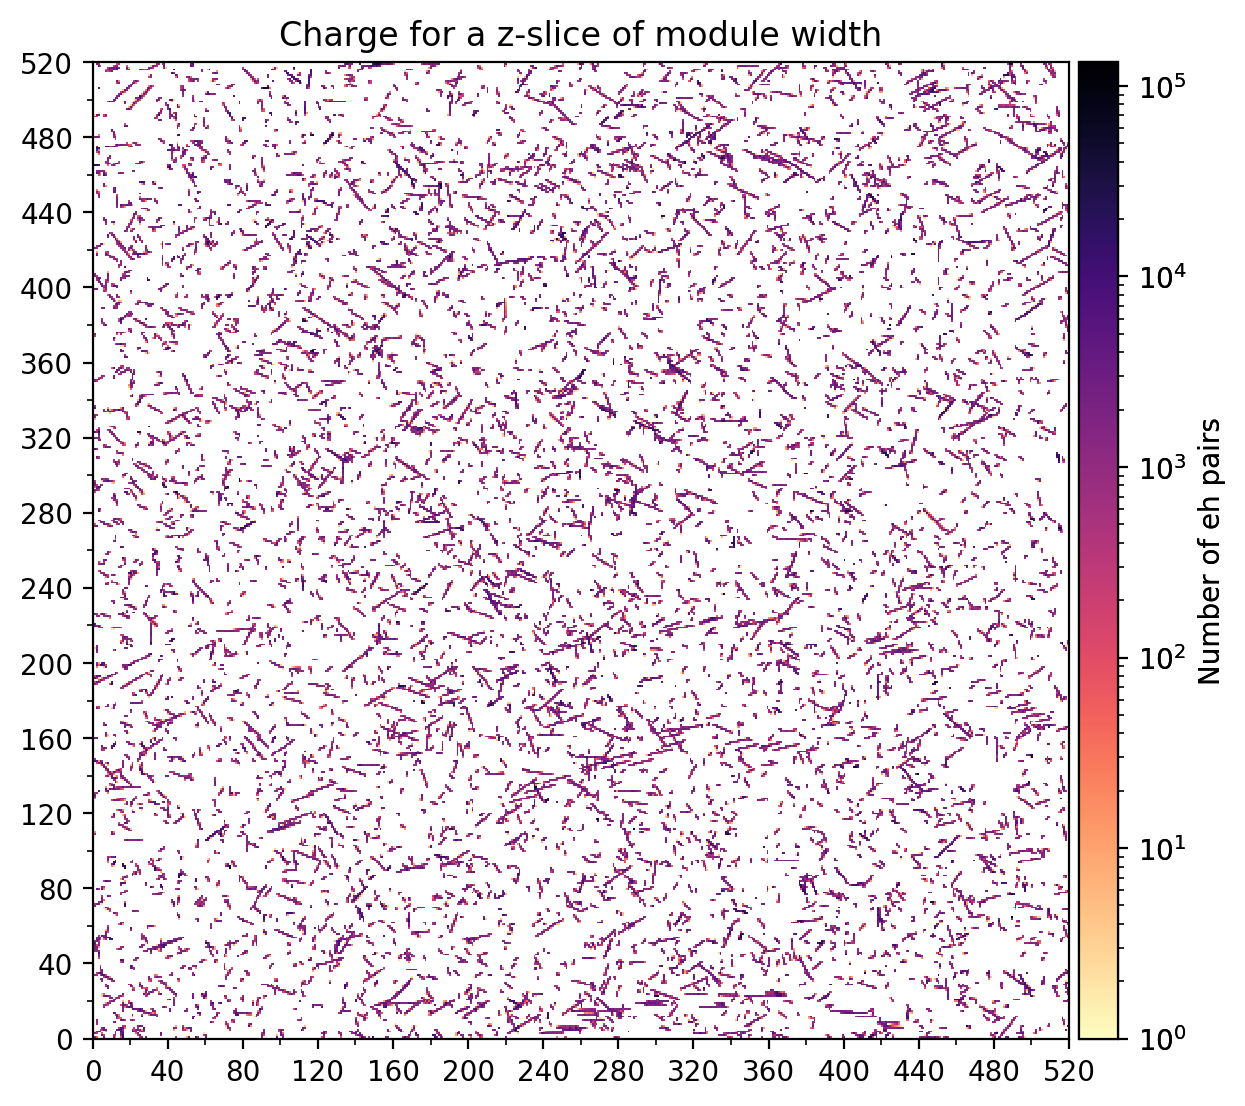

In [129]:

def plotMod(mod_array):
    fig, ax = plt.subplots(figsize=(7,7),dpi=200)

    # Plot charge collected in each pixel
    #datamin = mod_array.min()
    #datamax = mod_array.max()
    im = ax.imshow(mod_array, 
                   #vmin=datamin, 
                   #vmax=datamax, 
                   cmap='magma_r', 
                   interpolation='nearest', norm='log')
    

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')
    ax.set_title("Charge for a z-slice of module width")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')

    # Draw grid on both
    ax.set_xlim(0,520)
    ax.set_ylim(0,520)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    #ax.grid(which="minor", color="grey", linestyle='-', linewidth=0.2,snap=False)
    
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()

plotMod(module)

(array([ 6622, 28021]),)
Series([], Name: cotb, dtype: float64)
Series([], Name: cota, dtype: float64)


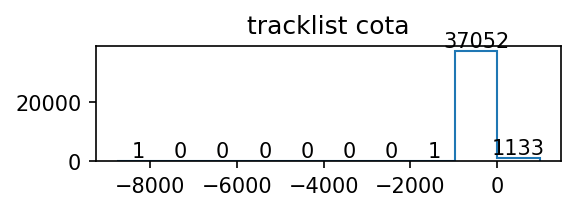

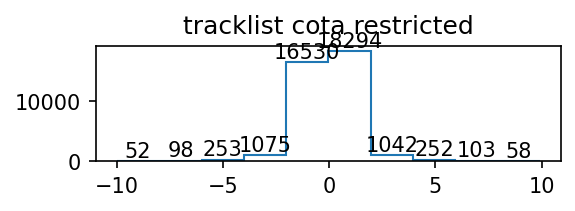

37601


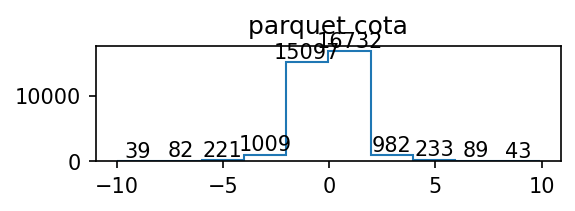

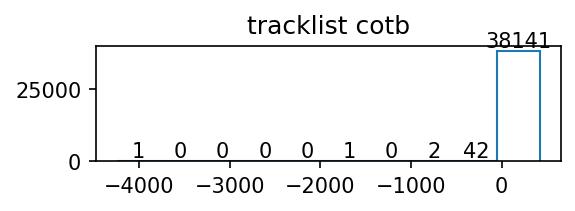

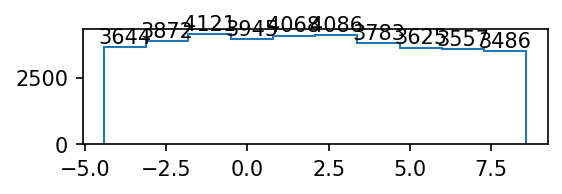

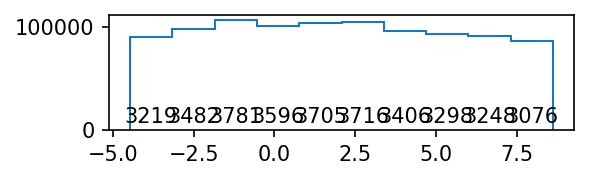

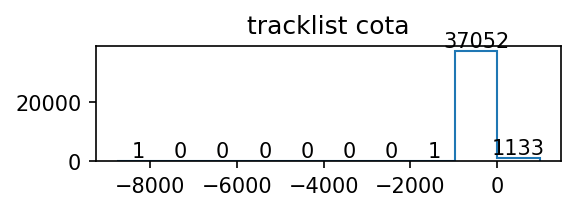

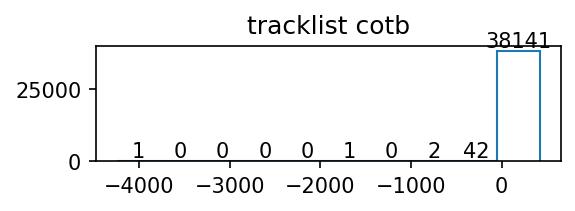

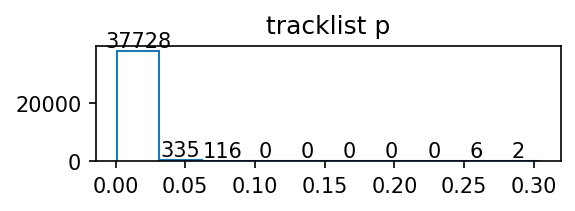

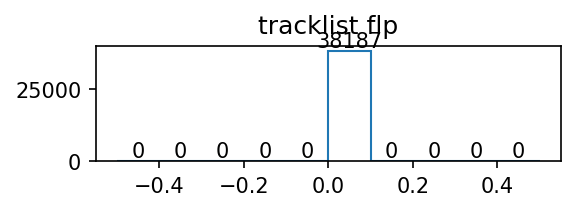

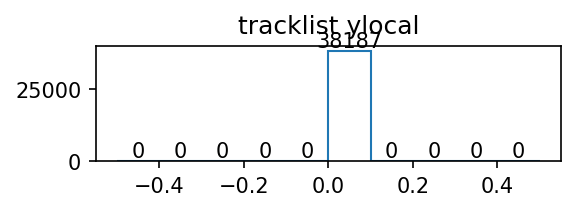

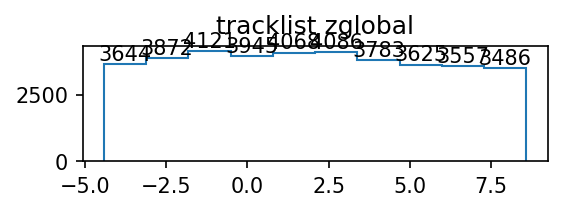

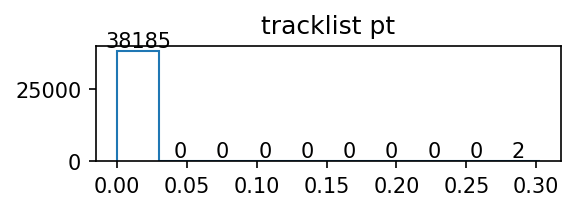

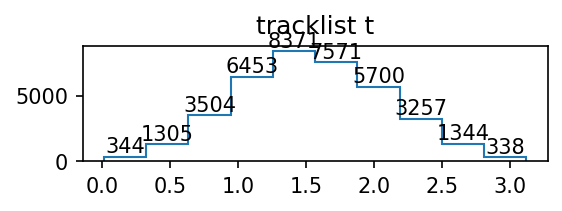

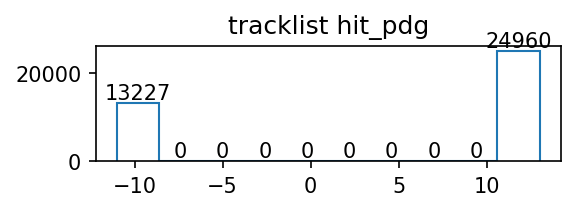

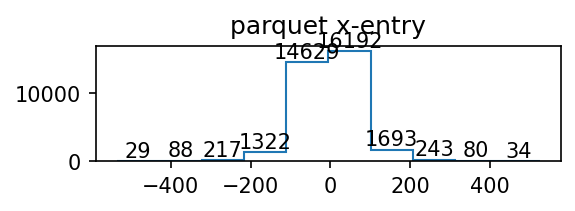

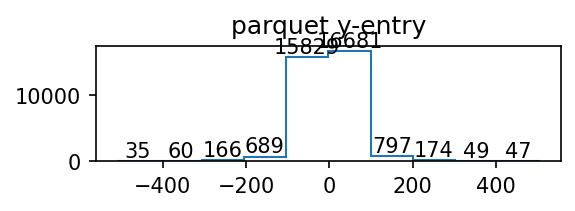

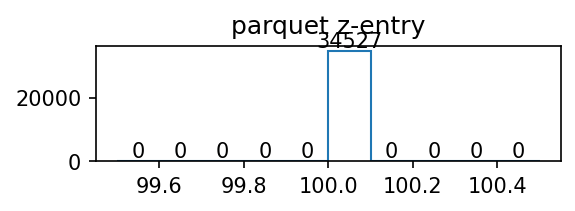

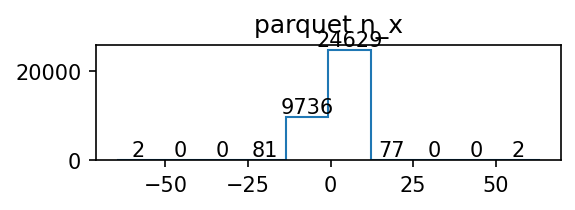

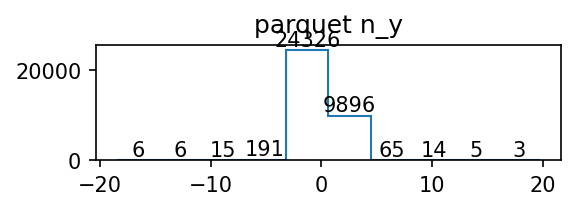

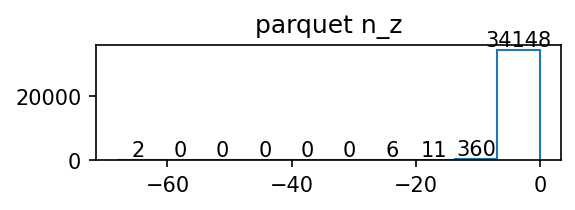

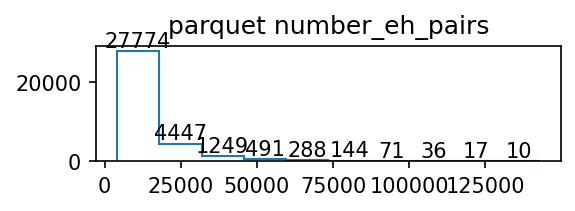

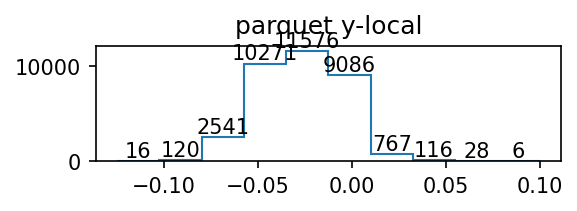

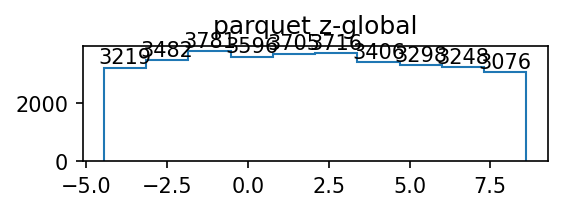

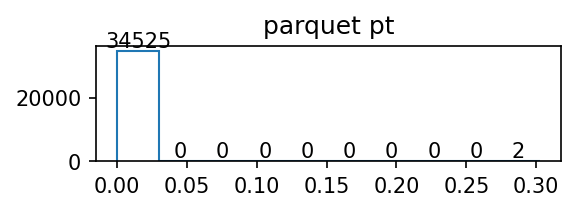

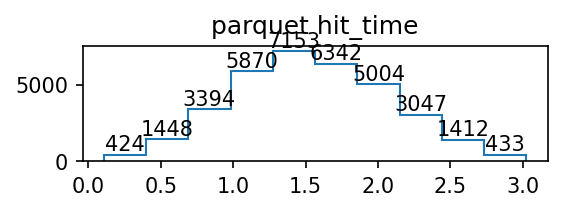

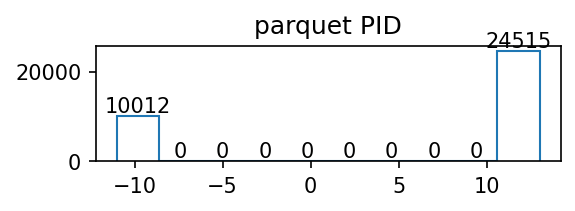

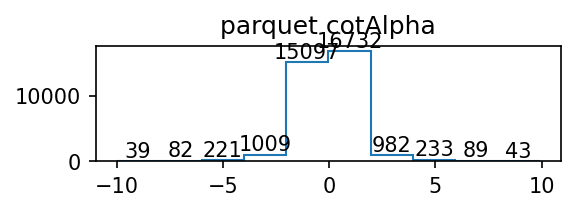

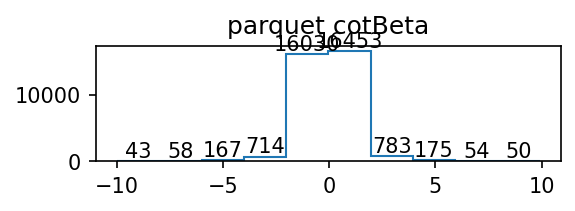

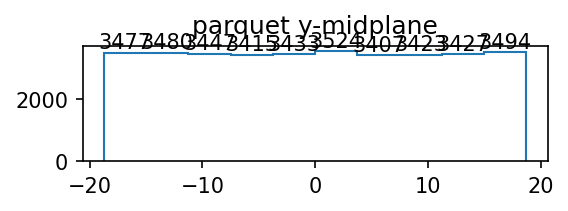

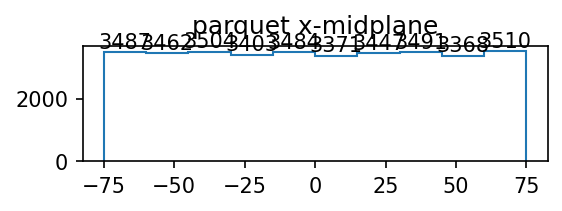

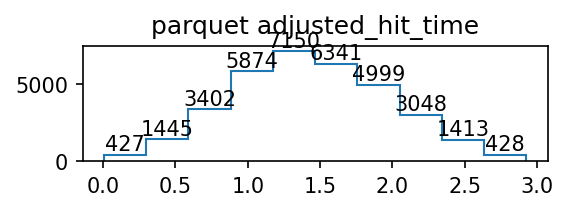

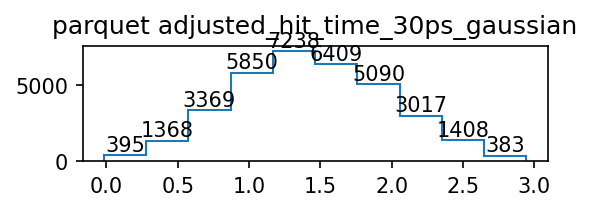

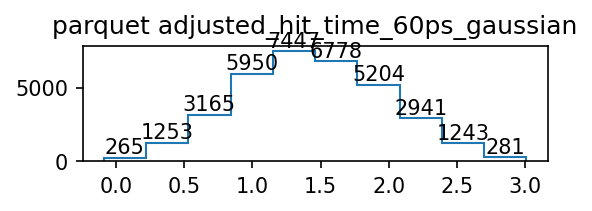

In [94]:
def plotHisto(arr,bins=None,postScale=1,title=""):
    plt.figure(figsize=(4,1))
    if bins==None:
        hist, bin_edges = np.histogram(arr)
    else:
        hist, bin_edges = np.histogram(arr,bins=bins)
    plt.stairs(hist*postScale,bin_edges)
    for i in range(len(hist)):
        # Calculate the x-coordinate for the center of the bar
        bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
        # Place the text slightly above the top of the bar
        plt.text(bin_center, hist[i], int(hist[i]), ha='center', va='bottom')
    plt.title(title)
    plt.show()
    return hist,bin_edges
# hist,bin_edges = plotHisto(trackData["cota"],bins=100)
# print(hist)
print(np.where(trackData["cotb"]<-1000))
print(trackData["cotb"][(trackData["cotb"]>800)])
print(trackData["cota"][(trackData["cotb"]>800)])
plotHisto(trackData["cota"],title="tracklist cota")
plotHisto(trackData["cota"][np.logical_and(trackData["cota"]>-10,trackData["cota"]<10)],title="tracklist cota restricted")
print(np.size(trackData["cota"][np.logical_and(np.logical_and(trackData["cota"]>-10,trackData["cota"]<10),np.logical_and(trackData["cotb"]<10,trackData["cotb"]>-10))]))
plotHisto(truthbib["cotAlpha"],title="parquet cota")
plotHisto(trackData["cotb"],title="tracklist cotb")
plotHisto(trackData["zglobal"])
plotHisto(truthbib["z-global"],postScale=28)
for key in trackData.keys():
    plotHisto(trackData[key],title=f"tracklist {key}")
for key in truthbib.keys():
    plotHisto(truthbib[key],title=f"parquet {key}")

In [95]:
print(np.where(truthbib["pt"]>0.57))

(array([], dtype=int64),)


In [96]:
def get_charge_center(cluster):
    charge = np.zeros(13)
    pixelNo = np.arange(0,13) 
    for i in range(13):
        charge[i] = np.sum(cluster[i])

    centery = int(np.round(np.sum(charge*pixelNo)/np.sum(charge)))

    clusterTest = cluster.T
    charge = np.zeros(21)
    pixelNo = np.arange(0,21) 
    for i in range(21):
        charge[i] = np.sum(clusterTest[i])

    centerx = int(np.round(np.sum(charge*pixelNo)/np.sum(charge)))

    return centerx, centery

In [105]:
cmap = mcolors.LinearSegmentedColormap.from_list("", ["white","red","darkred"])
colors = [(1,1,1),
          (252/256,80/256,76/256),
          (177/256,7/256,3/256)]
cmap = mcolors.LinearSegmentedColormap.from_list("", colors )
cmap = mcolors.LinearSegmentedColormap.from_list("", ["white","red","green","blue"] )

def plotSingleCluster(cluster):
    fig, ax = plt.subplots(figsize=(7,5),dpi=200)

    # Plot charge collected in each pixel
    datamin = cluster.min()
    datamax = cluster.max()
    im = ax.imshow(cluster, vmin=datamin, vmax=datamax, cmap=cmap, interpolation='nearest')
    centerx, centery = get_charge_center(cluster)
    # ax.hlines(y=centery,xmax=20,xmin=0)
    # ax.vlines(x=centerx,ymax=12, ymin=0)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')
    ax.set_title("Charge collected by 4 ns")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')

    # Draw grid on both
    ax.set_xlim(-0.5,20.5)
    ax.set_ylim(-0.5,12.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax.grid(which="minor", color="grey", linestyle='-', linewidth=0.5,snap=False)
    
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()

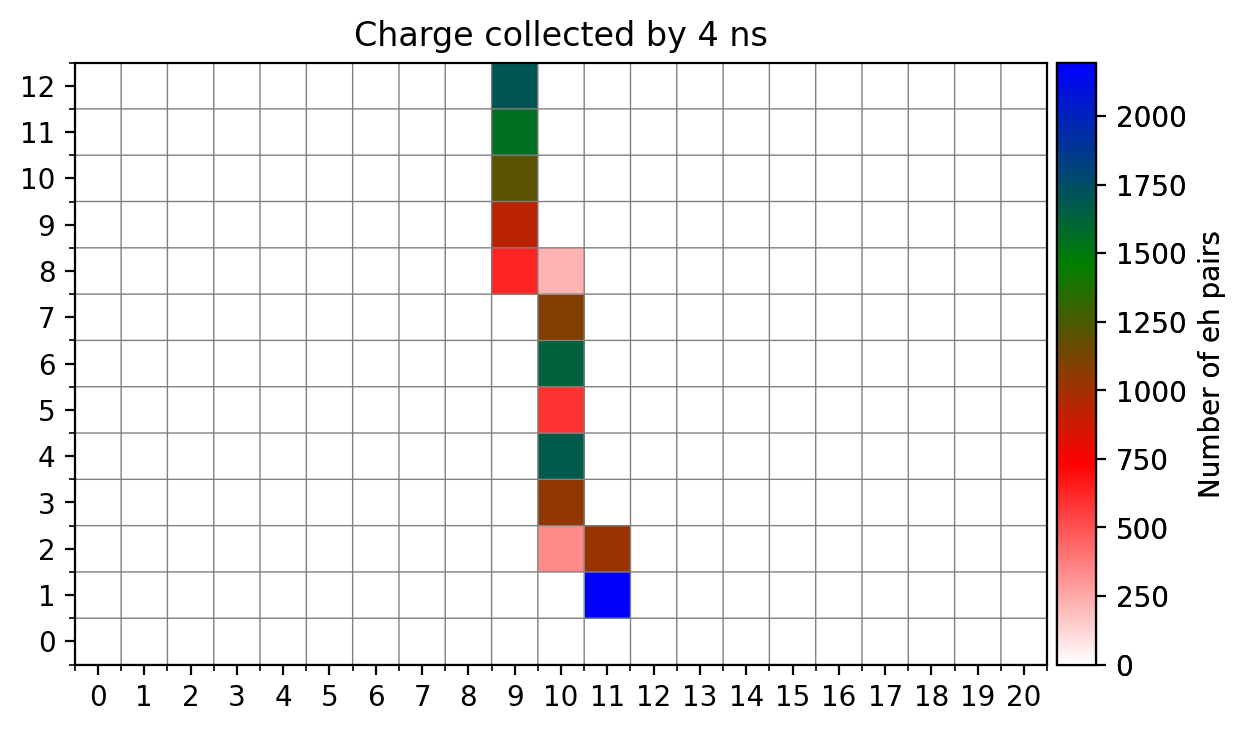

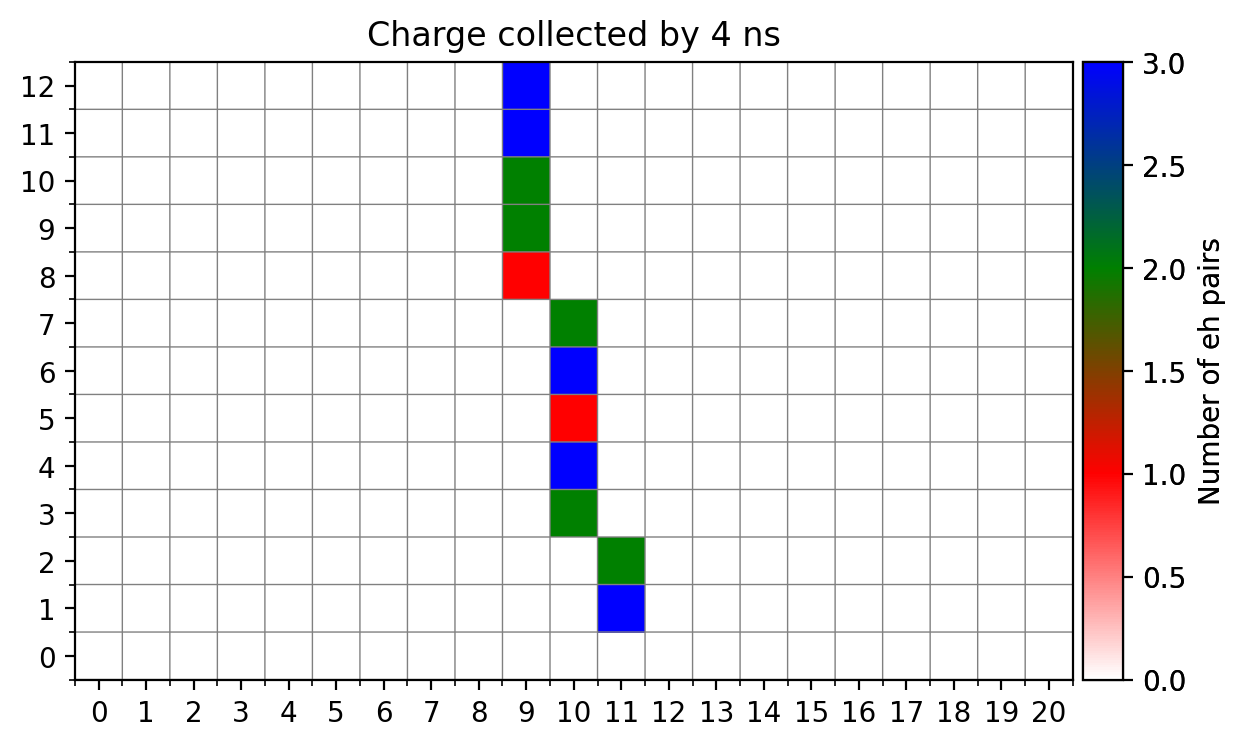

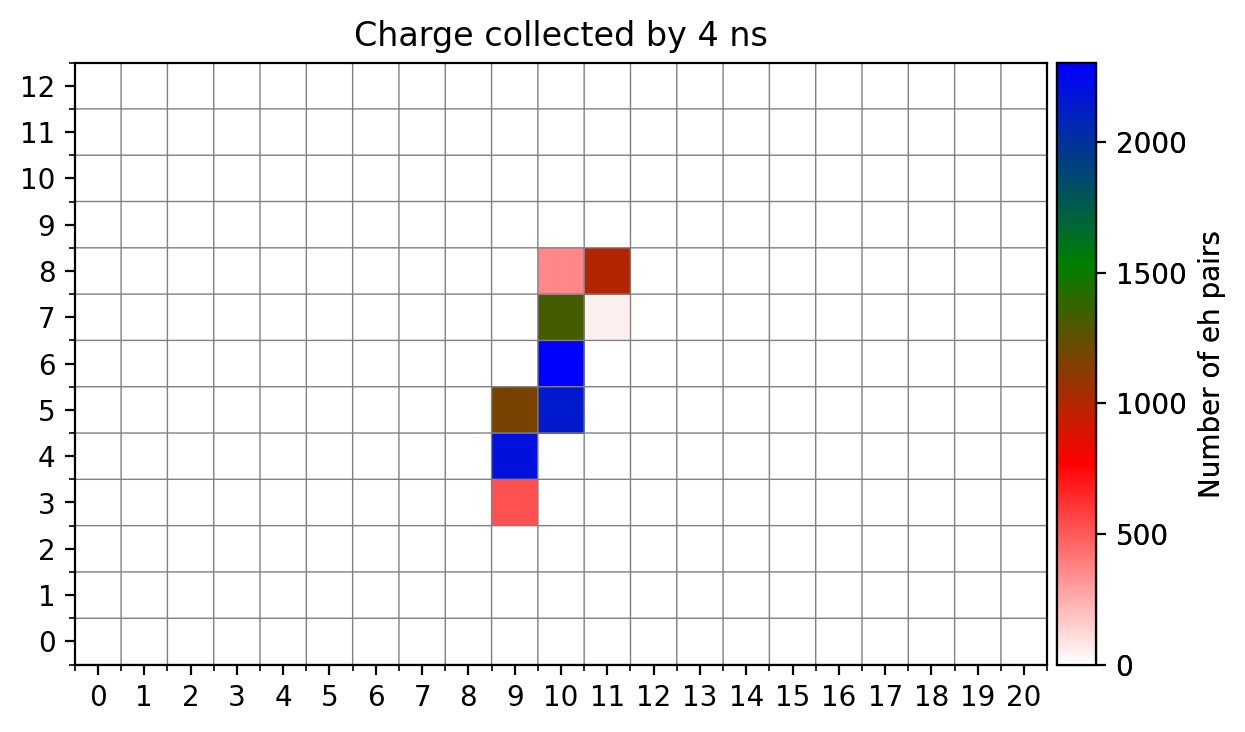

In [108]:
# plotSingleCluster(clustersBib[320])
plotSingleCluster(clustersBib[293])
quantizedCluster = clustersBib[293].copy()
quantizedCluster[quantizedCluster>1400] = 3
quantizedCluster[quantizedCluster>800] = 2
quantizedCluster[quantizedCluster>400] = 1
quantizedCluster[quantizedCluster>3] = 0
plotSingleCluster(quantizedCluster)
plotSingleCluster(clustersBib[26817])

In [99]:
truthbib['z-global']

0      1.34959
1      2.96027
2      3.39692
3     -4.15483
4      2.99962
        ...   
482    2.14349
483    3.93773
484    4.90888
485    4.89283
486    0.98985
Name: z-global, Length: 34527, dtype: float64

In [100]:
min(truthbib['z-global'])

-4.4635299999999996